In [76]:
import random
import matplotlib.pyplot as plt
import sys
sys.path.append("../src")
import pandas as pd
import numpy as np
from agents.agent import Agent , MomentumTrader, ContrarianTrader
from market.market import Market

In [77]:
agents = []

INITIAL_PRICE = 100

for i in range(40):
    agents.append(
        Agent(
            identity=f"N{i}",
            cash=random.randint(5000, 20000),
            holdings=random.randint(20, 100),
            risk_tolerance=random.uniform(0.2, 1.0)
        )
    )

for i in range(30):
    agents.append(
        MomentumTrader(
            identity=f"M{i}",
            cash=random.randint(5000, 20000),
            holdings=random.randint(20, 100),
            risk_tolerance=random.uniform(0.2, 1.0)
        )
    )

for i in range(30):
    agents.append(
        ContrarianTrader(
            identity=f"C{i}",
            cash=random.randint(5000, 20000),
            holdings=random.randint(20, 100),
            risk_tolerance=random.uniform(0.2, 1.0)
        )
    )

# initialize wealth
for agent in agents:
    agent.wealth = agent.cash + agent.holdings * INITIAL_PRICE

print("Total agents:", len(agents))

Total agents: 100


In [78]:
market = Market(
    current_price=INITIAL_PRICE,
    sensitivity=0.08
)

TICKS = 500

previous_price = INITIAL_PRICE

for tick in range(TICKS):

    # -----------------------------
    # Price movement signal
    # -----------------------------

    if tick == 0:
        price_movement = 0
    else:
        price_movement = (
            market.current_price - previous_price
        ) / previous_price

    previous_price = market.current_price

    # -----------------------------
    # Agents act
    # -----------------------------

    actions = []

    for agent in agents:

        act, vol = agent.action(
            market.current_price,
            price_movement
        )

        actions.append((act, vol))

        agent.update_values(
            market.current_price,
            act,
            vol
        )

        agent.log_tick(
            tick,
            market.current_price,
            act,
            vol
        )

    # -----------------------------
    # Market aggregates
    # -----------------------------

    market.agents_act(actions)

    new_price = market.pricing(tick)

    # -----------------------------
    # Update wealth after repricing
    # -----------------------------

    for agent in agents:
        agent.update_wealth(new_price)

print("Simulation complete")

Simulation complete


In [79]:
market_df = pd.DataFrame(market.price_history)

agent_history = []

for agent in agents:
    agent_history.extend(agent.agent_history)

agent_df = pd.DataFrame(agent_history)

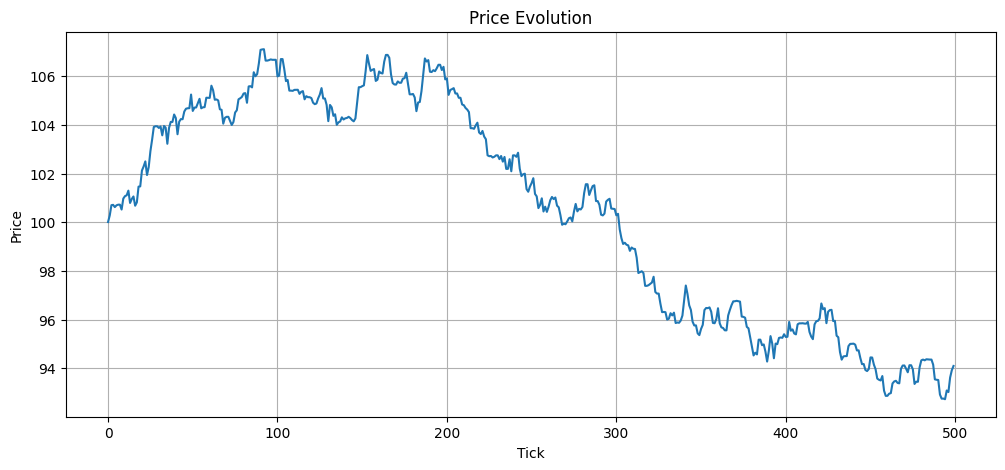

In [80]:
plt.figure(figsize=(12,5))
plt.plot(market_df["tick"], market_df["price"])
plt.title("Price Evolution")
plt.xlabel("Tick")
plt.ylabel("Price")
plt.grid(True)
plt.show()

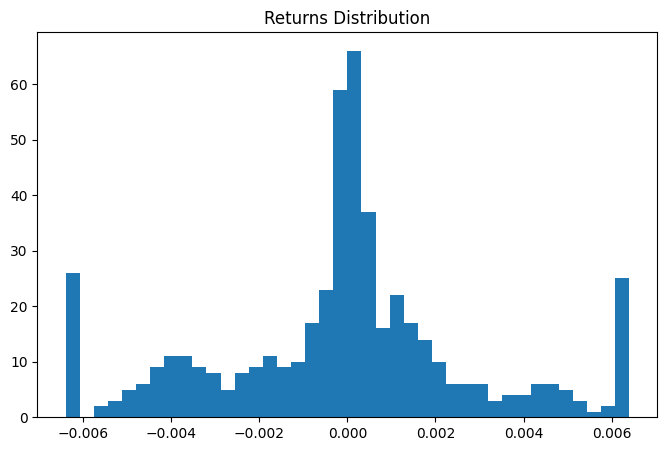

In [81]:
plt.figure(figsize=(8,5))
plt.hist(market_df["returns"], bins=40)
plt.title("Returns Distribution")
plt.show()

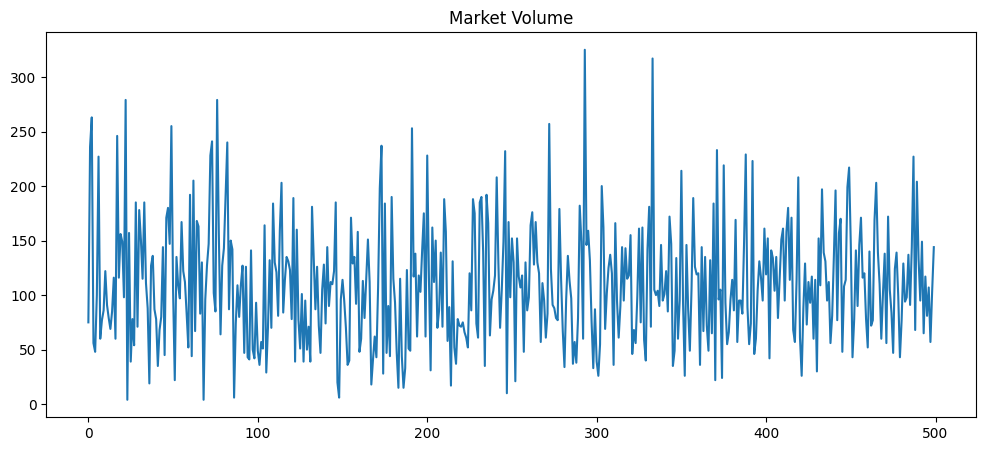

In [82]:
plt.figure(figsize=(12,5))
plt.plot(
    market_df["tick"],
    market_df["total_volume"]
)
plt.title("Market Volume")
plt.show()

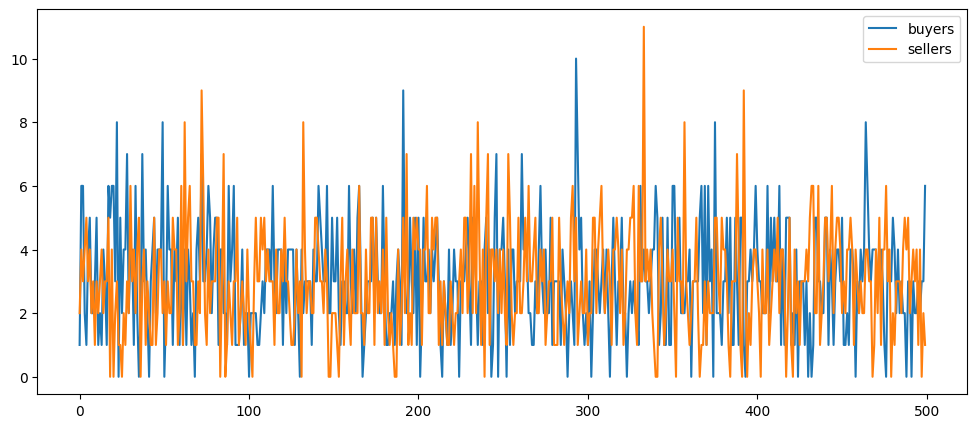

In [83]:
plt.figure(figsize=(12,5))

plt.plot(
    market_df["tick"],
    market_df["buyer"],
    label="buyers"
)

plt.plot(
    market_df["tick"],
    market_df["seller"],
    label="sellers"
)

plt.legend()
plt.show()

In [84]:
final_stats = []

for a in agents:
    final_stats.append({
        "id": a.id,
        "type": a.type,
        "wealth": a.wealth,
        "cash": a.cash,
        "holdings": a.holdings,
        "pnl": np.mean(a.pNl)
    })

final_df = pd.DataFrame(final_stats)

final_df.groupby("type")["wealth"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
contrarian,30.0,17063.308262,5181.716680,8156.098100,12718.324704,16761.927385,21372.803567,25779.076593
momentum,30.0,17683.786348,4851.313002,9138.429463,14625.976670,17266.387334,21291.777114,27065.469921
normal,40.0,17056.319154,4897.620210,7491.276129,13488.383924,16411.975658,19674.386245,27765.498799


In [85]:
final_stats = []

for a in agents:
    final_stats.append({
        "id": a.id,
        "type": a.type,
        "wealth": a.wealth,
        "cash": a.cash,
        "holdings": a.holdings,
        "pnl": np.mean(a.pNl)
    })

final_df = pd.DataFrame(final_stats)

final_df.groupby("type")["wealth"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
contrarian,30.0,17063.308262,5181.716680,8156.098100,12718.324704,16761.927385,21372.803567,25779.076593
momentum,30.0,17683.786348,4851.313002,9138.429463,14625.976670,17266.387334,21291.777114,27065.469921
normal,40.0,17056.319154,4897.620210,7491.276129,13488.383924,16411.975658,19674.386245,27765.498799


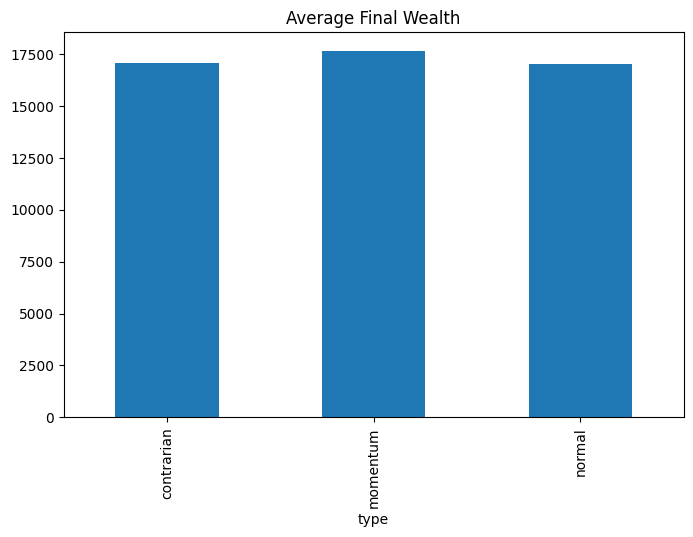

In [86]:
final_df.groupby("type")["wealth"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Final Wealth")
plt.show()

In [87]:
returns = market_df["returns"]

print("Final Price:", market_df["price"].iloc[-1])

print("Average Return:",
      returns.mean())

print("Return Volatility:",
      returns.std())

print("Max Return:",
      returns.max())

print("Min Return:",
      returns.min())

print("Average Volume:",
      market_df["total_volume"].mean())

Final Price: 94.09379376778969
Average Return: -0.00011740656921575642
Return Volatility: 0.0029497431166081913
Max Return: 0.006398862323351283
Min Return: -0.006398361809695069
Average Volume: 109.596
